FIRST FIND THE DATA TYPE 
# 🇫🇮 Finnish Population Shifts: Prediction, Explanation & Visualization

**Objective:** Analyze Helsinki district-level population data (2003–2023), build predictive and explanatory models, and forecast population changes through 2040.

**Dataset:** `Population2003-2023.xlsx` — Helsinki Statistics, via Avoindata.fi  
**Variables:** Population change, births, deaths, natural increase, in/out migration (internal + cross-border), by district and sub-district

---
## Project goals
1. Clean and combine yearly Excel sheets.
2. Visualize population changes from 2003 to 2023.
3. Explain key drivers: births, deaths, natural increase, and migration.
4. Forecast population change up to 2040.
5. Cluster Helsinki areas by growth and migration patterns.
6. Detect unusual population shifts using anomaly detection.

---

# Population Shifts in Helsinki 2003–2023: Prediction, Explanation and Visualization

## Project Objective

This project analyzes population changes in Helsinki from 2003 to 2023 using official population-change data by area and district.

The goal is to understand how Helsinki’s population has changed, what factors explain the change, and how population change may develop in the future.

The analysis focuses on:

- Population change over time
- Births and deaths
- Natural population increase
- Migration in and out of Helsinki areas
- Growing and declining areas
- Forecasting future population change
- Clustering areas by demographic patterns
- Detecting unusual population shifts

## Dataset

The dataset contains yearly population-change statistics for Helsinki areas and districts from 2003 to 2023.

The year 2017 is missing from the dataset, so it is excluded from the analysis.

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [ ]:
print("imported successfully.")

imported successfully.


In [23]:
load_data="Population2003-2023.xlsx"
excel_file = pd.ExcelFile(load_data)

print(excel_file.sheet_names)

['Kuvaus', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2018', '2019', '2020', '2021', '2022', '2023']


based on this output 2017 years data sheet is nor avaliable to checka and predict the data 

In [149]:
df_test = pd.read_excel(load_data, sheet_name=year_sheets[0])

print("Original column names:")
print(df_test.columns)

df_test.head(10)

Original column names:
Index(['Taulu 18  Väestönmuutokset piireittäin ja osa-alueittain 2003',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')


,Taulu 18 Väestönmuutokset piireittäin ja osa-alueittain 2003,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Befolkningsförändringar enli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Suurpiiri,Väkiluvun,Synty-,Kuol-,Synt.,Muutaneet yht.,NaN,NaN,Hgin rajan yli,NaN,NaN,Hgin sisällä,NaN,NaN
3,Peruspiiri,muutos yht.,neet,leet,enemm.,tulo,lähtö,netto,tulo,lähtö,netto,tulo,lähtö,netto
4,Osa-alue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Koko Helsinki,-386,6299,5163,1136,120168,121709,-1541,30960,32501,-1541,89208,89208,0
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1 Eteläinen suurpiiri,-541,1034,763,271,23387,23926,-539,6834,6354,480,16553,17572,-1019
9,101 Vironniemi,-102,110,84,26,2451,2543,-92,723,624,99,1728,1919,-191


In [24]:
year_sheets = [
    sheet for sheet in excel_file.sheet_names
    if sheet.isdigit()
]

print("Year sheets found:")
print(year_sheets)

print("Number of year sheets:", len(year_sheets))

Year sheets found:
['2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2018', '2019', '2020', '2021', '2022', '2023']
Number of year sheets: 20


as per uper output i found a lot of sheet in my excel file so i need combine it for future analysis and i need to remane each columes becouse of it is finnish words so i need to change in english

In [37]:
all_years_data = []

for sheet in year_sheets:
    year = int(sheet)

    df = pd.read_excel(load_data, sheet_name=sheet, header=None, skiprows=6)

    df = df.iloc[:, :14]

In [59]:
all_years_data = []

column_names = [
    "Area",
    "Population_Change",
    "Births",
    "Deaths",
    "Natural_Increase",
    "Total_Migration_In",
    "Total_Migration_Out",
    "Total_Net_Migration",
    "External_Migration_In",
    "External_Migration_Out",
    "External_Net_Migration",
    "Internal_Migration_In",
    "Internal_Migration_Out",
    "Internal_Net_Migration"
]

for sheet in year_sheets:
    year = int(sheet)

    df = pd.read_excel(load_data, sheet_name=sheet, header=None)

    # Find the row where "Koko Helsinki" appears
    koko_row = df[df.apply(lambda row: row.astype(str).str.contains("Koko Helsinki").any(), axis=1)]

    if koko_row.empty:
        continue

    start_index = koko_row.index[0]

    # Take data starting from that row
    df = df.iloc[start_index:]

    # Keep only first 14 columns
    df = df.iloc[:, :14]

    # Drop empty columns
    df = df.dropna(axis=1, how="all")

    # Ensure 14 columns
    while df.shape[1] < 14:
        df[df.shape[1]] = np.nan

    df.columns = column_names
    df["Year"] = year

    all_years_data.append(df)

data_raw = pd.concat(all_years_data, ignore_index=True)

print("Combined shape:", data_raw.shape)
data_raw.head()

Combined shape: (3645, 15)


,Area,Population_Change,Births,Deaths,Natural_Increase,Total_Migration_In,Total_Migration_Out,Total_Net_Migration,External_Migration_In,External_Migration_Out,External_Net_Migration,Internal_Migration_In,Internal_Migration_Out,Internal_Net_Migration,Year
0,Koko Helsinki,-386,6299,5163,1136,120168,121709,-1541,30960,32501,-1541,89208,89208,0,2003
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003
2,1 Eteläinen suurpiiri,-541,1034,763,271,23387,23926,-539,6834,6354,480,16553,17572,-1019,2003
3,101 Vironniemi,-102,110,84,26,2451,2543,-92,723,624,99,1728,1919,-191,2003
4,010 Kruununhaka,-68,69,51,18,1594,1667,-73,465,401,64,1129,1266,-137,2003


based on this output i found some value are NaN, so it might be a missing or empty so i need to clean first.

In [61]:
data = data_raw[data_raw["Area"].notna()].copy()
data["Area"] = data["Area"].astype(str).str.strip()
data = data[data["Area"] != ""]
print("Cleaned shape:", data.shape)
data.head()

Cleaned shape: (3428, 15)


,Area,Population_Change,Births,Deaths,Natural_Increase,Total_Migration_In,Total_Migration_Out,Total_Net_Migration,External_Migration_In,External_Migration_Out,External_Net_Migration,Internal_Migration_In,Internal_Migration_Out,Internal_Net_Migration,Year
0,Koko Helsinki,-386,6299,5163,1136,120168,121709,-1541,30960,32501,-1541,89208,89208,0,2003
2,1 Eteläinen suurpiiri,-541,1034,763,271,23387,23926,-539,6834,6354,480,16553,17572,-1019,2003
3,101 Vironniemi,-102,110,84,26,2451,2543,-92,723,624,99,1728,1919,-191,2003
4,010 Kruununhaka,-68,69,51,18,1594,1667,-73,465,401,64,1129,1266,-137,2003
5,020 Kluuvi,-2,1,1,0,121,124,-3,49,46,3,72,78,-6,2003


In [62]:
print(sorted(data["Year"].unique()))
print("Rows per year:")
print(data["Year"].value_counts().sort_index())

[np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Rows per year:
Year
2003    157
2004    157
2005    157
2006    169
2007    155
2008    165
2009    164
2010    163
2011    179
2012    169
2013    170
2014    186
2015    185
2016    188
2018    172
2019    186
2020    184
2021    174
2022    174
2023    174
Name: count, dtype: int64


In [63]:
data[data["Year"] == 2003].head(3)
data[data["Year"] == 2010].head(3)
data[data["Year"] == 2023].head(3)
print("Total rows:", len(data))
print("Total areas:", data["Area"].nunique())

Total rows: 3428
Total areas: 210


we know the colmus and data type but for make sure for applying a machine learning model we need a numeric data type.

In [64]:
numeric_cols = [
    "Population_Change",
    "Births",
    "Deaths",
    "Natural_Increase",
    "Total_Migration_In",
    "Total_Migration_Out",
    "Total_Net_Migration",
    "External_Migration_In",
    "External_Migration_Out",
    "External_Net_Migration",
    "Internal_Migration_In",
    "Internal_Migration_Out",
    "Internal_Net_Migration"
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Data types after conversion:")
print(data.dtypes)

Data types after conversion:
Area                       object
Population_Change         float64
Births                    float64
Deaths                    float64
Natural_Increase          float64
Total_Migration_In        float64
Total_Migration_Out       float64
Total_Net_Migration       float64
External_Migration_In     float64
External_Migration_Out    float64
External_Net_Migration    float64
Internal_Migration_In     float64
Internal_Migration_Out    float64
Internal_Net_Migration    float64
Year                        int64
dtype: object


In [65]:
data.describe()

,Population_Change,Births,Deaths,Natural_Increase,Total_Migration_In,Total_Migration_Out,Total_Net_Migration,External_Migration_In,External_Migration_Out,External_Net_Migration,Internal_Migration_In,Internal_Migration_Out,Internal_Net_Migration,Year
count,3401.000000,3384.000000,3349.000000,3384.000000,3399.000000,3401.000000,3400.000000,3043.000000,3039.000000,3042.000000,3042.000000,3046.000000,3043.000000,3428.000000
mean,157.439577,191.963357,143.435354,50.011525,3474.347749,3352.805057,119.534706,1118.132764,990.595920,128.881328,2624.250164,2642.208470,-21.425567,2013.067970
std,631.830373,642.819612,488.840846,177.626946,11943.913069,11597.782372,530.839626,3724.157378,3343.039477,556.071454,8812.958122,8839.158766,312.002111,6.079695
min,-1647.000000,0.000000,0.000000,-1006.000000,0.000000,0.000000,-5508.000000,0.000000,0.000000,-3235.000000,0.000000,0.000000,-3563.000000,2003.000000
25%,-21.000000,25.000000,11.000000,1.000000,312.000000,285.000000,-30.000000,105.000000,105.000000,-9.000000,268.250000,252.250000,-82.000000,2008.000000
50%,11.000000,62.000000,42.000000,13.000000,1007.000000,957.000000,6.000000,321.000000,296.000000,18.000000,813.500000,798.500000,-11.000000,2013.000000
75%,114.000000,120.250000,105.000000,41.000000,2297.500000,2226.000000,100.000000,795.000000,636.000000,106.000000,1746.750000,1798.750000,28.000000,2019.000000
max,8696.000000,7082.000000,5929.000000,1881.000000,149439.000000,149442.000000,7118.000000,45760.000000,42732.000000,6916.000000,106710.000000,106710.000000,3177.000000,2023.000000


In [66]:
helsinki = data[data["Area"] == "Koko Helsinki"].copy()
helsinki = helsinki.sort_values("Year")

print("Years available for Koko Helsinki:")
print(helsinki["Year"].tolist())

print("Number of rows:", len(helsinki))

helsinki[["Year", "Population_Change", "Natural_Increase", "Total_Net_Migration"]]

Years available for Koko Helsinki:
[2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023]
Number of rows: 20


,Year,Population_Change,Natural_Increase,Total_Net_Migration
0,2003,-386.0,1136.0,-1541.0
167,2004,-284.0,1135.0,-1392.0
334,2005,1859.0,1318.0,572.0
501,2006,3616.0,1214.0,2347.0
680,2007,4010.0,1180.0,2776.0
844,2008,8101.0,1517.0,4499.0
1020,2009,6718.0,1576.0,5164.0
1195,2010,5199.0,1600.0,3608.0
1369,2011,6835.0,1639.0,5431.0
1559,2012,8584.0,1674.0,6916.0


now we need to show a some visulation for understand a trand in helsinki areas wise.

In [67]:
helsinki = data[data["Area"] == "Koko Helsinki"]

helsinki.head()

,Area,Population_Change,Births,Deaths,Natural_Increase,Total_Migration_In,Total_Migration_Out,Total_Net_Migration,External_Migration_In,External_Migration_Out,External_Net_Migration,Internal_Migration_In,Internal_Migration_Out,Internal_Net_Migration,Year
0,Koko Helsinki,-386.0,6299.0,5163.0,1136.0,120168.0,121709.0,-1541.0,30960.0,32501.0,-1541.0,89208.0,89208.0,0.0,2003
167,Koko Helsinki,-284.0,6180.0,5045.0,1135.0,119068.0,120460.0,-1392.0,31985.0,33377.0,-1392.0,87083.0,87083.0,0.0,2004
334,Koko Helsinki,1859.0,6103.0,4785.0,1318.0,123424.0,122852.0,572.0,33953.0,33381.0,572.0,89471.0,89471.0,0.0,2005
501,Koko Helsinki,3616.0,6156.0,4942.0,1214.0,117424.0,115077.0,2347.0,34715.0,32368.0,2347.0,82709.0,82709.0,0.0,2006
680,Koko Helsinki,4010.0,6079.0,4899.0,1180.0,118779.0,116003.0,2776.0,35830.0,33054.0,2776.0,82949.0,82949.0,0.0,2007


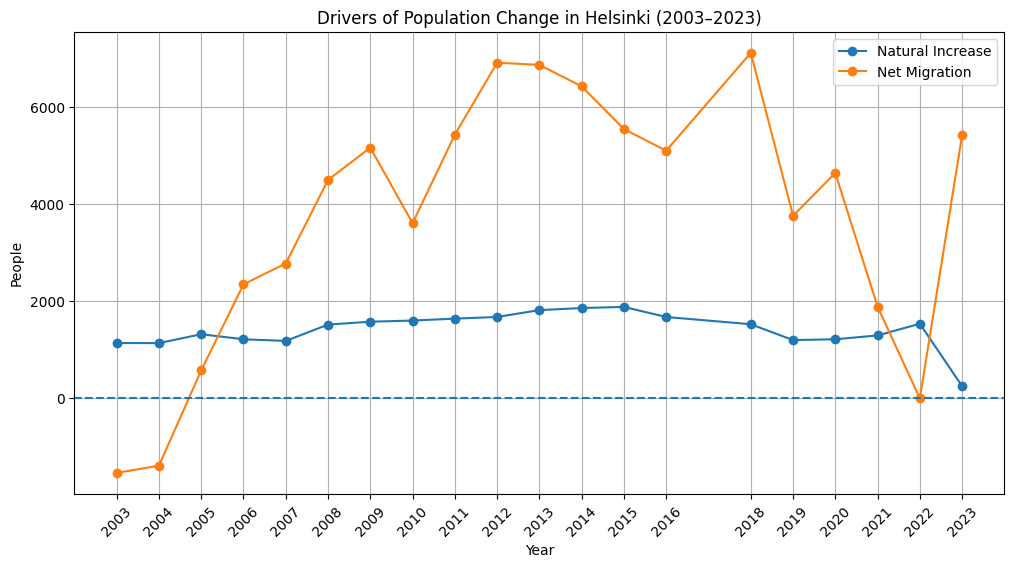

In [69]:
plt.figure(figsize=(12,6))

plt.plot(helsinki["Year"], helsinki["Natural_Increase"], marker="o", label="Natural Increase")
plt.plot(helsinki["Year"], helsinki["Total_Net_Migration"], marker="o", label="Net Migration")

plt.axhline(0, linestyle="--")

plt.title("Drivers of Population Change in Helsinki (2003–2023)")
plt.xlabel("Year")
plt.ylabel("People")
plt.xticks(helsinki["Year"], rotation=45)
plt.legend()
plt.grid(True)

plt.show()

As per a line chart to show the natural increase which is come from a natural death-brith = natural increase. and other line a orange is showing a net migration like a people moving in - people moving out in Helsinki and based on this since a 2003 to 2004 migration is low but after 2012 to 2018 is peaks migration but after 2022 it is drop down sharply but next year like a 2023 rise agin very rapidly  " Migration is unstable but powerful"

In [158]:
top_areas = (
    data.groupby("Area")["Population_Change"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = data[data["Area"].isin(top_areas)]


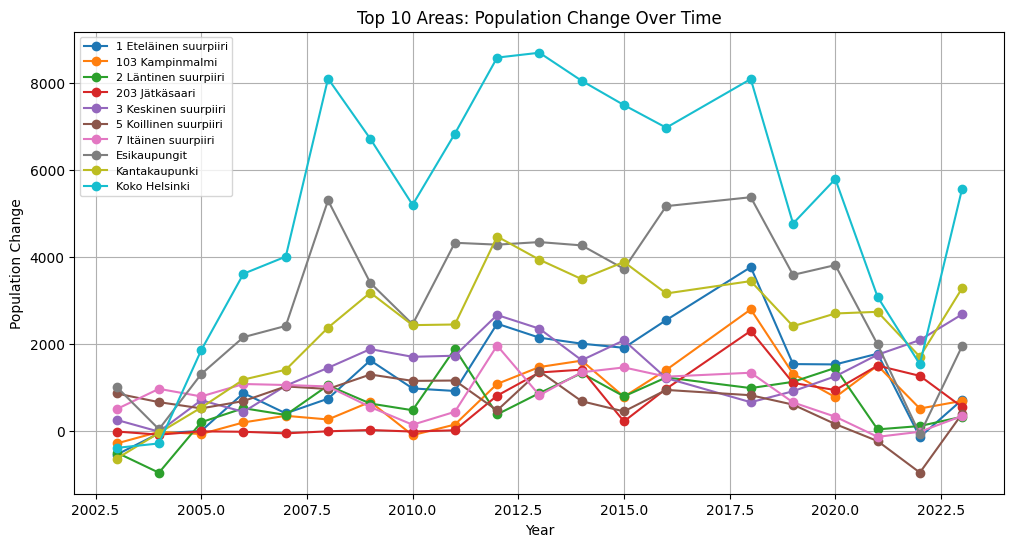

In [ ]:
pivot_top = df_top.pivot_table(
    values="Population_Change",
    index="Year",
    columns="Area",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))

for col in pivot_top.columns:
    plt.plot(
        pivot_top.index,
        pivot_top[col],
        marker="o",
        label=col
    )
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title("Top 10 Areas: Population Change Over Time")
plt.xlabel("Year")
plt.ylabel("Population Change")

plt.legend(fontsize=8)
plt.grid(True)

plt.show()

In [160]:
top_areas = (
    data.groupby("Area")["Population_Change"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
    .index
)

df_top = data[data["Area"].isin(top_areas)]

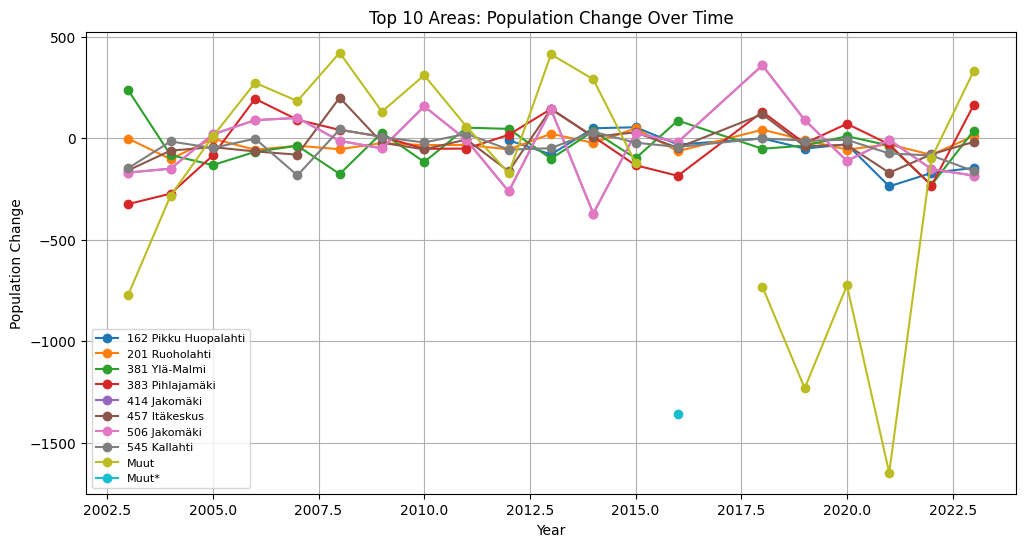

In [ ]:
pivot_top = df_top.pivot_table(
    values="Population_Change",
    index="Year",
    columns="Area",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))

for col in pivot_top.columns:
    plt.plot(
        pivot_top.index,
        pivot_top[col],
        marker="o",
        label=col
    )
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.title("Top 10 Areas: Population Change Over Time")
plt.xlabel("Year")
plt.ylabel("Population Change")

plt.legend(fontsize=8)
plt.grid(True)

plt.show()

This chart shows population change over time for the top 10 areas with the highest overall growth. Each line represents one area, making it easy to compare how population trends differ across locations.

as we know the helsinki information but what about the a areas wise a information.

In [ ]:
area_growth = data.groupby("Area")["Population_Change"].sum().sort_values(ascending=False)
area_growth = area_growth[~area_growth.index.str.contains("Muut")] # there are some "Muut" areas that are not relevant for our analysis, so we can exclude them
top_growth = area_growth.head(10)

top_decline = area_growth.tail(10)

print("Top 10 Growing Areas:")
print(top_growth)
print("\nTop 10 Declining Areas:")
print(top_decline)

Top 10 Growing Areas:
Area
Koko Helsinki            104312.0
Esikaupungit              60882.0
Kantakaupunki             48152.0
3 Keskinen suurpiiri      28538.0
1 Eteläinen suurpiiri     25253.0
7 Itäinen suurpiiri       15966.0
103 Kampinmalmi           15158.0
5 Koillinen suurpiiri     13095.0
2 Läntinen suurpiiri      12379.0
203 Jätkäsaari            12308.0
Name: Population_Change, dtype: float64

Top 10 Declining Areas:
Area
101 Vilhonvuori        -421.0
386 Pihlajisto         -425.0
506 Jakomäki           -519.0
414 Jakomäki           -519.0
383 Pihlajamäki        -523.0
201 Ruoholahti         -542.0
457 Itäkeskus          -543.0
381 Ylä-Malmi          -635.0
162 Pikku Huopalahti   -654.0
545 Kallahti           -827.0
Name: Population_Change, dtype: float64


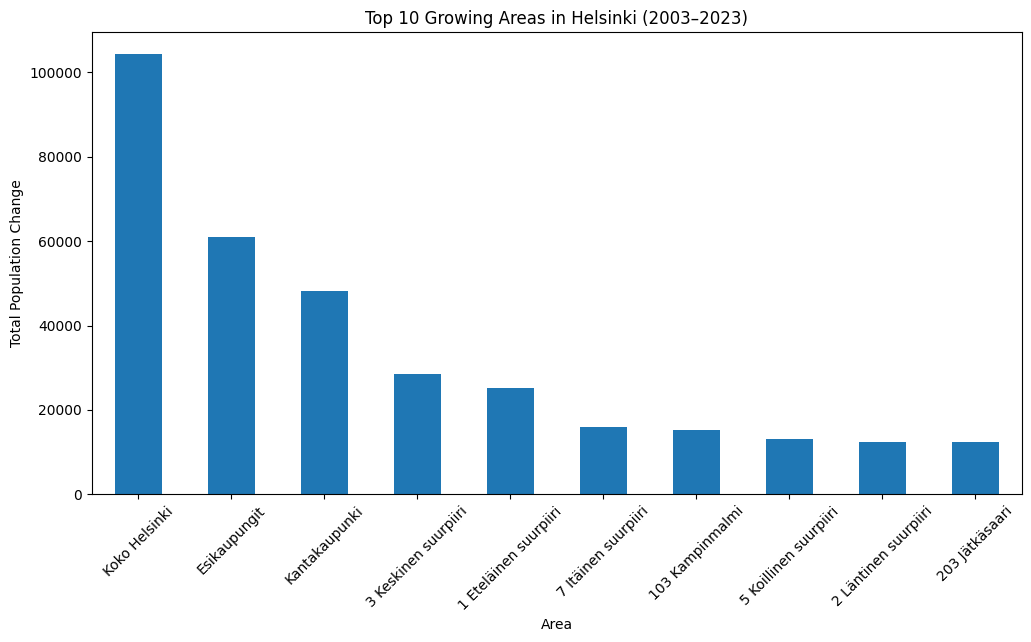

In [71]:
plt.figure(figsize=(12,6))

top_growth.plot(kind="bar")
plt.title("Top 10 Growing Areas in Helsinki (2003–2023)")
plt.ylabel("Total Population Change")
plt.xticks(rotation=45)

plt.show()

Population growth in Helsinki is not evenly distributed. While the city overall is growing, certain areas such as Jätkäsaari and central districts show strong growth, likely due to new development and urbanization. At the same time, some older residential areas experience decline, indicating internal migration patterns within the city.

In [75]:
area_analysis = data.groupby("Area")[[
    "Population_Change",
    "Natural_Increase",
    "Total_Net_Migration"
]].sum()
area_analysis = area_analysis[
    ~area_analysis.index.str.contains(r"\*|\)", regex=True)
]

area_analysis.head()

,Population_Change,Natural_Increase,Total_Net_Migration
Area,,,
010 Kruununhaka,459.0,623.0,309.0
020 Kluuvi,275.0,40.0,312.0
030 Kaartinkaupunki,155.0,126.0,148.0
040 Kamppi,1764.0,734.0,1656.0
050 Punavuori,895.0,744.0,919.0


i will add one columes called a growth type like a showing a reason why populcation increas in this areas.

In [76]:
def classify(row):
    if row["Total_Net_Migration"] > row["Natural_Increase"]:
        return "Migration-driven"
    elif row["Natural_Increase"] > row["Total_Net_Migration"]:
        return "Natural-growth"
    else:
        return "Balanced"

area_analysis["Growth_Type"] = area_analysis.apply(classify, axis=1)

area_analysis.head()

,Population_Change,Natural_Increase,Total_Net_Migration,Growth_Type
Area,,,,
010 Kruununhaka,459.0,623.0,309.0,Natural-growth
020 Kluuvi,275.0,40.0,312.0,Migration-driven
030 Kaartinkaupunki,155.0,126.0,148.0,Migration-driven
040 Kamppi,1764.0,734.0,1656.0,Migration-driven
050 Punavuori,895.0,744.0,919.0,Migration-driven


## Now we moved a Ml Model part i will predict future populcation change in helsinki upcoming 2030 to 2040.

it is just predictation but future will depands on conutry rules and regucaltion based for migration and local people.

In [ ]:
#i will select only the total Helsinki rows.Because forecasting all areas at once is harder. We first predict the whole city trend.
helsinki = data[data["Area"] == "Koko Helsinki"].copy()

In [78]:
helsinki = helsinki.sort_values("Year")
X = helsinki[["Year"]]
y = helsinki["Population_Change"]

In [ ]:
model = LinearRegression()
model.fit(X, y)
future_years = pd.DataFrame({
    "Year": list(range(2024, 2041))
})
predictions = model.predict(future_years)

In [80]:
future_years["Predicted_Population_Change"] = predictions
future_years

,Year,Predicted_Population_Change
0,2024,6786.029740
1,2025,6926.246681
2,2026,7066.463622
3,2027,7206.680563
4,2028,7346.897504
5,2029,7487.114445
6,2030,7627.331386
7,2031,7767.548327
8,2032,7907.765268
9,2033,8047.982209


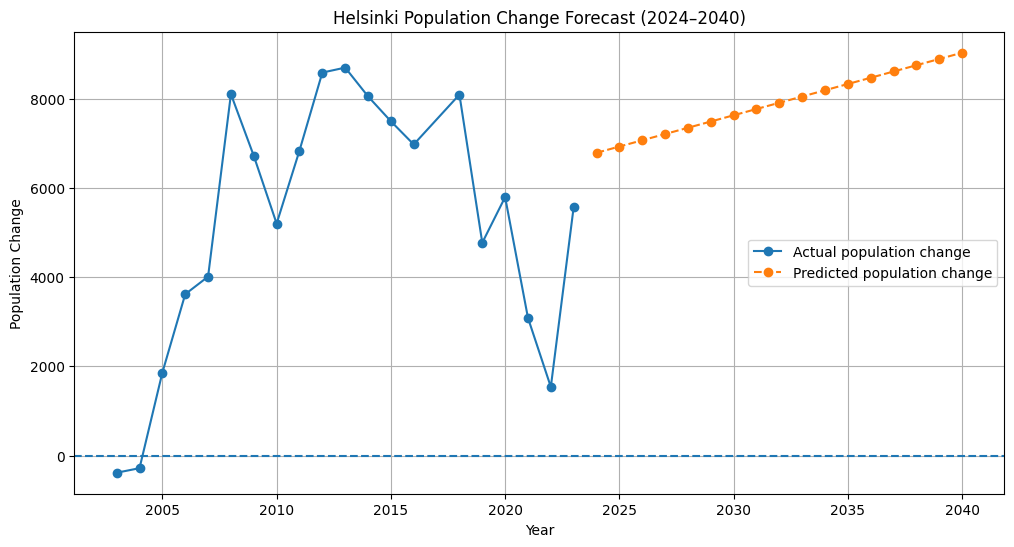

In [81]:
plt.figure(figsize=(12,6))

plt.plot(
    helsinki["Year"],
    helsinki["Population_Change"],
    marker="o",
    label="Actual population change"
)

plt.plot(
    future_years["Year"],
    future_years["Predicted_Population_Change"],
    linestyle="--",
    marker="o",
    label="Predicted population change"
)

plt.axhline(0, linestyle="--")

plt.title("Helsinki Population Change Forecast (2024–2040)")
plt.xlabel("Year")
plt.ylabel("Population Change")
plt.legend()
plt.grid(True)

plt.show()

In [90]:
all_area_forecasts = []

for area in data["Area"].unique():
    area_data = data[data["Area"] == area].copy()
    area_data = area_data.sort_values("Year")

    # Remove rows where Population_Change is missing
    area_data = area_data.dropna(subset=["Population_Change", "Year"])

    # Skip areas with too few valid years
    if len(area_data) < 5:
        continue

    X = area_data[["Year"]]
    y = area_data["Population_Change"]

    model = LinearRegression()
    model.fit(X, y)

    future_years = pd.DataFrame({
        "Year": list(range(2024, 2041))
    })

    predictions = model.predict(future_years)

    forecast_df = future_years.copy()
    forecast_df["Area"] = area
    forecast_df["Predicted_Population_Change"] = predictions

    all_area_forecasts.append(forecast_df)

area_forecasts = pd.concat(all_area_forecasts, ignore_index=True)

print("Forecast created for areas:", area_forecasts["Area"].nunique())
area_forecasts.head()

Forecast created for areas: 192


,Year,Area,Predicted_Population_Change
0,2024,Koko Helsinki,6786.029740
1,2025,Koko Helsinki,6926.246681
2,2026,Koko Helsinki,7066.463622
3,2027,Koko Helsinki,7206.680563
4,2028,Koko Helsinki,7346.897504


In [106]:
# data["Area"] = data["Area"].astype(str)
# data["Area_Name"] = data["Area"].str.replace(r"^\d+\s*", "", regex=True)
# data["Area_Name"] = data["Area_Name"].str.strip()
# combined = data.groupby("Area_Name")["Population_Change"].sum()
# combined = combined.sort_values(ascending=False)

# combined.head(50)

In [104]:

summary = area_forecasts.groupby("Area")[
    "Predicted_Population_Change"
].sum().sort_values(ascending=False)

summary.head(50)

Area
Koko Helsinki                 134432.009559
Kantakaupunki                  82316.997345
Esikaupungit                   68338.984334
1 Eteläinen suurpiiri          46327.525624
3 Keskinen suurpiiri           45476.593468
103 Kampinmalmi                37315.157993
203 Jätkäsaari                 37065.913436
6 Kaakkoinen suurpiiri         34769.997079
210 Hermanni                   29685.305556
301 Kallio                     28753.245220
102 Kalasatama                 25511.564331
2 Läntinen suurpiiri           22781.564126
603 Laajasalo                  21795.767260
310 Lauttasaari                20516.638889
494 Kruunuvuorenranta          18787.241401
304 Pasila                     16819.039830
335 Kuninkaantammi             15979.877128
205 Kaarela                    14645.773101
602 Herttoniemi                12150.923792
465 Pitäjänmäen teoll.          8603.700000
703 Mellunkylä                  8514.323155
100 Sörnäinen                   7920.583333
491 Yliskylä               

Clustering (Group Areas by Pattern)

for this ml model we will ues for a population change, natural growing and migration people.

In [111]:
area_analysis = area_analysis[
    ~area_analysis.index.str.contains("Muut", case=False)
]

In [112]:
area_analysis.head()

,Population_Change,Natural_Increase,Total_Net_Migration
Area,,,
010 Kruununhaka,459.0,623.0,309.0
020 Kluuvi,275.0,40.0,312.0
030 Kaartinkaupunki,155.0,126.0,148.0
040 Kamppi,1764.0,734.0,1656.0
050 Punavuori,895.0,744.0,919.0


In [115]:
area_analysis = area_analysis[
    ~area_analysis.index.str.contains(r"\*|\)", regex=True)
]

area_analysis = area_analysis[
    ~area_analysis.index.str.contains("Muut", case=False)
]

In [116]:
if "Cluster" in area_analysis.columns:
    area_analysis = area_analysis.drop(columns=["Cluster"])

as per dataset i will test first 3 cluster parameter and then i will usig a 4 parameter to better predictation.
in 3 paramenter means high growth, declining and stable but on ther other side for 4 parameter we can see a very high growth, moderate growth, stable and declining.

In [117]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(area_analysis)

kmeans = KMeans(n_clusters=3, random_state=42)
area_analysis["Cluster"] = kmeans.fit_predict(scaled_data)

area_analysis.head()

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster
Area,,,,
010 Kruununhaka,459.0,623.0,309.0,2
020 Kluuvi,275.0,40.0,312.0,2
030 Kaartinkaupunki,155.0,126.0,148.0,2
040 Kamppi,1764.0,734.0,1656.0,2
050 Punavuori,895.0,744.0,919.0,2


In [121]:
area_analysis.groupby("Cluster").mean()


,Population_Change,Natural_Increase,Total_Net_Migration
Cluster,,,
0,14100.833333,4152.000000,11271.833333
1,71115.333333,21943.000000,52983.333333
2,825.225131,329.659686,608.570681


In [122]:
area_analysis[area_analysis["Cluster"] == 1].head(10)

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster
Area,,,,
Esikaupungit,60882.0,26955.0,37457.0,1
Kantakaupunki,48152.0,10649.0,46338.0,1
Koko Helsinki,104312.0,28225.0,75155.0,1


Now we can check growth using a 4 cluster.

In [123]:
kmeans4 = KMeans(n_clusters=4, random_state=42)

area_analysis["Cluster_4"] = kmeans4.fit_predict(scaled_data)

area_analysis.head()

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster,Cluster_4
Area,,,,,
010 Kruununhaka,459.0,623.0,309.0,2,2
020 Kluuvi,275.0,40.0,312.0,2,2
030 Kaartinkaupunki,155.0,126.0,148.0,2,2
040 Kamppi,1764.0,734.0,1656.0,2,2
050 Punavuori,895.0,744.0,919.0,2,2


In [ ]:
area_analysis.groupby("Cluster_4").mean()

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster
Cluster_4,,,,
0,14100.833333,4152.000000,11271.833333,0.0
1,104312.000000,28225.000000,75155.000000,1.0
2,825.225131,329.659686,608.570681,2.0
3,54517.000000,18802.000000,41897.500000,1.0


In [130]:
area_analysis.sort_values("Cluster_4").head(100)

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster,Cluster_4
Area,,,,,
103 Kampinmalmi,15158.0,3162.0,12083.0,0,0
1 Eteläinen suurpiiri,25253.0,9242.0,19277.0,0,0
203 Jätkäsaari,12308.0,1141.0,9499.0,0,0
2 Läntinen suurpiiri,12379.0,5099.0,10406.0,0,0
301 Kallio,9581.0,419.0,11405.0,0,0
305 Vanhakaupunki,8708.0,1501.0,7674.0,0,0
3 Keskinen suurpiiri,28538.0,3093.0,30149.0,0,0
5 Koillinen suurpiiri,13095.0,9705.0,4157.0,0,0
7 Itäinen suurpiiri,15966.0,5620.0,12117.0,0,0


In [133]:
for i in range(4):
    print(f"\nCluster {i}:")
    print(area_analysis[area_analysis["Cluster_4"] == i].index.tolist())
cluster_table = area_analysis.reset_index()[["Area", "Cluster_4"]]
cluster_table.head(100)


Cluster 0:
['1 Eteläinen suurpiiri', '103 Kampinmalmi', '2 Läntinen suurpiiri', '203 Jätkäsaari', '3 Keskinen suurpiiri', '301 Kallio', '305 Vanhakaupunki', '5 Koillinen suurpiiri', '501 Latokartano', '6 Kaakkoinen suurpiiri', '7 Itäinen suurpiiri', '704 Vuosaari']

Cluster 1:
['Koko Helsinki']

Cluster 2:
['010 Kruununhaka', '020 Kluuvi', '030 Kaartinkaupunki', '040 Kamppi', '050 Punavuori', '060 Eira', '070 Ullanlinna', '080 Katajanokka', '090 Kaivopuisto', '100 Sörnäinen', '101 Vilhonvuori', '101 Vironniemi', '102 Kalasatama', '102 Ullanlinna', '103 Sompasaari', '104 Taka-Töölö', '105 Lauttasaari', '111 Siltasaari', '112 Linjat', '113 Torkkelinmäki', '121 Harju', '122 Alppila', '130 Etu-Töölö', '140 Taka-Töölö', '150 Meilahti', '160 Ruskeasuo', '161 Vanha Ruskeasuo', '162 Pikku Huopalahti', '171 Länsi-Pasila', '172 Pohjois-Pasila', '173 Itä-Pasila', '174 Keski-Pasila', '180 Laakso', '190 Mustikkamaa-Korkea', '190 Mustikkamaa-Korkeas.', '201 Reijola', '201 Ruoholahti', '202 Lapinlah

,Area,Cluster_4
0,010 Kruununhaka,2
1,020 Kluuvi,2
2,030 Kaartinkaupunki,2
3,040 Kamppi,2
4,050 Punavuori,2
5,060 Eira,2
6,070 Ullanlinna,2
7,080 Katajanokka,2
8,090 Kaivopuisto,2
9,1 Eteläinen suurpiiri,0



 Stable / Low Growth
['010 Kruununhaka', '020 Kluuvi', '030 Kaartinkaupunki', '040 Kamppi', '050 Punavuori', '060 Eira', '070 Ullanlinna', '080 Katajanokka', '090 Kaivopuisto', '100 Sörnäinen', '101 Vilhonvuori', '101 Vironniemi', '102 Kalasatama', '102 Ullanlinna', '103 Sompasaari', '104 Taka-Töölö', '105 Lauttasaari', '111 Siltasaari', '112 Linjat', '113 Torkkelinmäki', '121 Harju', '122 Alppila', '130 Etu-Töölö', '140 Taka-Töölö', '150 Meilahti', '160 Ruskeasuo', '161 Vanha Ruskeasuo', '162 Pikku Huopalahti', '171 Länsi-Pasila', '172 Pohjois-Pasila', '173 Itä-Pasila', '174 Keski-Pasila', '180 Laakso', '190 Mustikkamaa-Korkea', '190 Mustikkamaa-Korkeas.', '201 Reijola', '201 Ruoholahti', '202 Lapinlahti', '202 Munkkiniemi', '203 Haaga', '204 Hernesaari', '204 Munkkisaari', '204 Pitäjänmäki', '205 Kaarela', '210 Hermanni', '211 Hermanninmäki', '212 Hermanninranta', '213 Kyläsaari', '220 Vallila', '230 Toukola', '231 Toukola', '232 Arabianranta', '240 Kumpula', '250 Käpylä', '260 Kosk

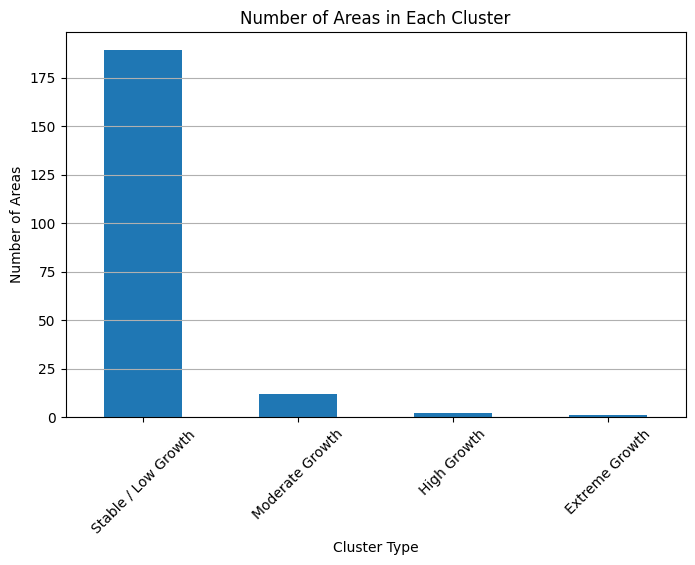

In [164]:
for label in area_analysis["Cluster_Label"].unique():
    print("\n", label)
    print(area_analysis[area_analysis["Cluster_Label"] == label].index.tolist())
cluster_counts = area_analysis["Cluster_Label"].value_counts()

plt.figure(figsize=(8, 5))

cluster_counts.plot(kind="bar")

plt.title("Number of Areas in Each Cluster")
plt.xlabel("Cluster Type")
plt.ylabel("Number of Areas")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

just like a Area - Kluuvi, Kamppi, Jätkäsaari and it is like a Stable, Moderate, High Growth.

In [138]:
def label_cluster(c):
    if c == 1:
        return "Extreme Growth"
    elif c == 3:
        return "High Growth"
    elif c == 0:
        return "Moderate Growth"
    elif c == 2:
        return "Stable / Low Growth"

area_analysis["Cluster_Label"] = area_analysis["Cluster_4"].apply(label_cluster)

area_analysis.head(15)

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster,Cluster_4,Cluster_Label
Area,,,,,,
010 Kruununhaka,459.0,623.0,309.0,2,2,Stable / Low Growth
020 Kluuvi,275.0,40.0,312.0,2,2,Stable / Low Growth
030 Kaartinkaupunki,155.0,126.0,148.0,2,2,Stable / Low Growth
040 Kamppi,1764.0,734.0,1656.0,2,2,Stable / Low Growth
050 Punavuori,895.0,744.0,919.0,2,2,Stable / Low Growth
060 Eira,-6.0,132.0,-115.0,2,2,Stable / Low Growth
070 Ullanlinna,680.0,931.0,430.0,2,2,Stable / Low Growth
080 Katajanokka,935.0,260.0,816.0,2,2,Stable / Low Growth
090 Kaivopuisto,-35.0,16.0,-30.0,2,2,Stable / Low Growth


In [136]:
area_analysis[area_analysis["Cluster_Label"] == "Extreme Growth"]

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster,Cluster_4,Cluster_Label
Area,,,,,,
Koko Helsinki,104312.0,28225.0,75155.0,1,1,Extreme Growth


In [140]:
area_analysis[["Population_Change", "Natural_Increase", "Total_Net_Migration", "Cluster_4", "Cluster_Label"]].sort_values("Cluster_4")


,Population_Change,Natural_Increase,Total_Net_Migration,Cluster_4,Cluster_Label
Area,,,,,
103 Kampinmalmi,15158.0,3162.0,12083.0,0,Moderate Growth
1 Eteläinen suurpiiri,25253.0,9242.0,19277.0,0,Moderate Growth
203 Jätkäsaari,12308.0,1141.0,9499.0,0,Moderate Growth
2 Läntinen suurpiiri,12379.0,5099.0,10406.0,0,Moderate Growth
301 Kallio,9581.0,419.0,11405.0,0,Moderate Growth
...,...,...,...,...,...
602 Herttoniemi,3626.0,2079.0,2635.0,2,Stable / Low Growth
8 Östersundomin suurpiiri,1785.0,52.0,-198.0,2,Stable / Low Growth
801 Östersundom,1785.0,52.0,-198.0,2,Stable / Low Growth


In [141]:
area_analysis = area_analysis[
    ~area_analysis.index.str.contains("Lähde", case=False)
]

Clustering reveals four types of areas: extreme growth, high growth, moderate growth, and stable areas. The results show that migration is the dominant factor driving population change, especially in rapidly developing areas such as Jätkäsaari and central districts.

## Anomaly Detection
for this Ml model i will using a isolation forest model, becouse of it is based on populcation drop and increase like a unusul growith.

In [142]:
helsinki = data[data["Area"] == "Koko Helsinki"].copy()
helsinki = helsinki.sort_values("Year")

helsinki[["Year", "Population_Change"]]

,Year,Population_Change
0,2003,-386.0
167,2004,-284.0
334,2005,1859.0
501,2006,3616.0
680,2007,4010.0
844,2008,8101.0
1020,2009,6718.0
1195,2010,5199.0
1369,2011,6835.0
1559,2012,8584.0


In [143]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.15, random_state=42)

helsinki["Anomaly"] = model.fit_predict(
    helsinki[["Population_Change"]]
)

helsinki

,Area,Population_Change,Births,Deaths,Natural_Increase,Total_Migration_In,Total_Migration_Out,Total_Net_Migration,External_Migration_In,External_Migration_Out,External_Net_Migration,Internal_Migration_In,Internal_Migration_Out,Internal_Net_Migration,Year,Area_Name,Anomaly
0,Koko Helsinki,-386.0,6299.0,5163.0,1136.0,120168.0,121709.0,-1541.0,30960.0,32501.0,-1541.0,89208.0,89208.0,0.0,2003,Koko Helsinki,-1
167,Koko Helsinki,-284.0,6180.0,5045.0,1135.0,119068.0,120460.0,-1392.0,31985.0,33377.0,-1392.0,87083.0,87083.0,0.0,2004,Koko Helsinki,-1
334,Koko Helsinki,1859.0,6103.0,4785.0,1318.0,123424.0,122852.0,572.0,33953.0,33381.0,572.0,89471.0,89471.0,0.0,2005,Koko Helsinki,1
501,Koko Helsinki,3616.0,6156.0,4942.0,1214.0,117424.0,115077.0,2347.0,34715.0,32368.0,2347.0,82709.0,82709.0,0.0,2006,Koko Helsinki,1
680,Koko Helsinki,4010.0,6079.0,4899.0,1180.0,118779.0,116003.0,2776.0,35830.0,33054.0,2776.0,82949.0,82949.0,0.0,2007,Koko Helsinki,1
844,Koko Helsinki,8101.0,6407.0,4890.0,1517.0,117155.0,112656.0,4499.0,36970.0,32471.0,4499.0,80185.0,80185.0,0.0,2008,Koko Helsinki,1
1020,Koko Helsinki,6718.0,6533.0,4957.0,1576.0,124864.0,119700.0,5164.0,37280.0,32116.0,5164.0,87584.0,87584.0,0.0,2009,Koko Helsinki,1
1195,Koko Helsinki,5199.0,6709.0,5109.0,1600.0,121516.0,117908.0,3608.0,35625.0,32017.0,3608.0,85891.0,85891.0,0.0,2010,Koko Helsinki,1
1369,Koko Helsinki,6835.0,6619.0,4980.0,1639.0,126135.0,120704.0,5431.0,38027.0,32596.0,5431.0,88108.0,88108.0,0.0,2011,Koko Helsinki,1
1559,Koko Helsinki,8584.0,6748.0,5074.0,1674.0,131731.0,124815.0,6916.0,39845.0,32929.0,6916.0,91886.0,91886.0,0.0,2012,Koko Helsinki,1


In [144]:
anomalies = helsinki[helsinki["Anomaly"] == -1]

anomalies

,Area,Population_Change,Births,Deaths,Natural_Increase,Total_Migration_In,Total_Migration_Out,Total_Net_Migration,External_Migration_In,External_Migration_Out,External_Net_Migration,Internal_Migration_In,Internal_Migration_Out,Internal_Net_Migration,Year,Area_Name,Anomaly
0,Koko Helsinki,-386.0,6299.0,5163.0,1136.0,120168.0,121709.0,-1541.0,30960.0,32501.0,-1541.0,89208.0,89208.0,0.0,2003,Koko Helsinki,-1
167,Koko Helsinki,-284.0,6180.0,5045.0,1135.0,119068.0,120460.0,-1392.0,31985.0,33377.0,-1392.0,87083.0,87083.0,0.0,2004,Koko Helsinki,-1
3275,Koko Helsinki,1537.0,7082.0,5548.0,1534.0,149439.0,149442.0,-3.0,42729.0,42732.0,-3.0,106710.0,106710.0,0.0,2022,Koko Helsinki,-1


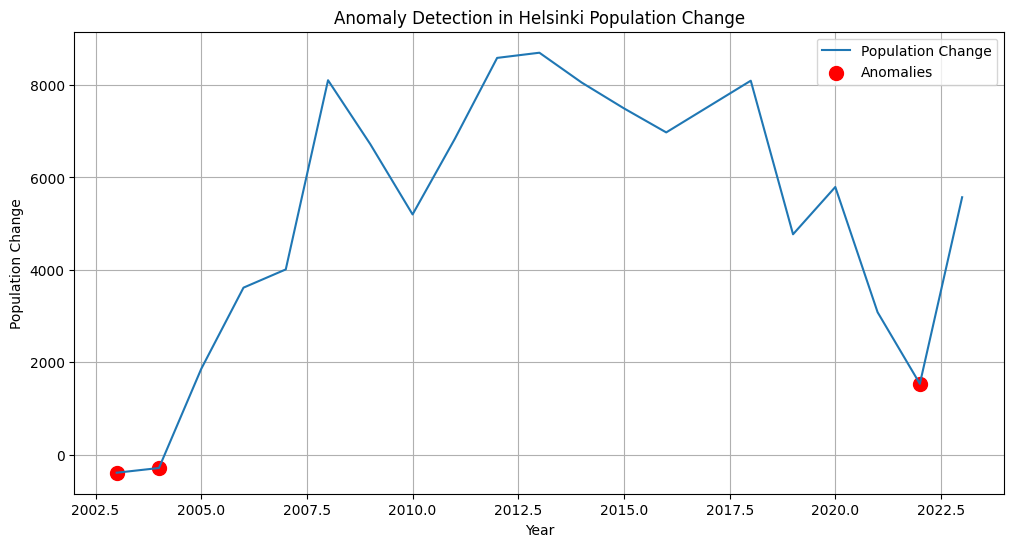

In [145]:
plt.figure(figsize=(12,6))

plt.plot(helsinki["Year"], helsinki["Population_Change"], label="Population Change")

# highlight anomalies
plt.scatter(
    anomalies["Year"],
    anomalies["Population_Change"],
    color="red",
    label="Anomalies",
    s=100
)

plt.title("Anomaly Detection in Helsinki Population Change")
plt.xlabel("Year")
plt.ylabel("Population Change")

plt.legend()
plt.grid(True)
plt.show()

Anomaly detection identified years where population change deviated significantly from the overall trend. Early years showed negative growth, while recent anomalies indicate sudden drops, likely influenced by external factors such as economic conditions or global events.

In [146]:
model = IsolationForest(contamination=0.05)

area_analysis["Anomaly"] = model.fit_predict(
    area_analysis[["Population_Change"]]
)

area_analysis[area_analysis["Anomaly"] == -1]

,Population_Change,Natural_Increase,Total_Net_Migration,Cluster,Cluster_4,Cluster_Label,Anomaly
Area,,,,,,,
1 Eteläinen suurpiiri,25253.0,9242.0,19277.0,0,0,Moderate Growth,-1
103 Kampinmalmi,15158.0,3162.0,12083.0,0,0,Moderate Growth,-1
203 Jätkäsaari,12308.0,1141.0,9499.0,0,0,Moderate Growth,-1
3 Keskinen suurpiiri,28538.0,3093.0,30149.0,0,0,Moderate Growth,-1
5 Koillinen suurpiiri,13095.0,9705.0,4157.0,0,0,Moderate Growth,-1
545 Kallahti,-827.0,1293.0,-1655.0,2,2,Stable / Low Growth,-1
6 Kaakkoinen suurpiiri,10078.0,3273.0,6834.0,0,0,Moderate Growth,-1
7 Itäinen suurpiiri,15966.0,5620.0,12117.0,0,0,Moderate Growth,-1
Esikaupungit,60882.0,26955.0,37457.0,1,3,High Growth,-1


now i am learn a new ml model called a Polynomial Regression which is avoid overfitting the data and give a better prediction.

In [150]:
helsinki = data[data["Area"] == "Koko Helsinki"].copy()
helsinki = helsinki.sort_values("Year")

X = helsinki[["Year"]]
y = helsinki["Population_Change"]

now ml model code

In [151]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y)

future_years = pd.DataFrame({
    "Year": list(range(2024, 2041))
})

future_poly = poly.transform(future_years)

predictions_poly = model_poly.predict(future_poly)

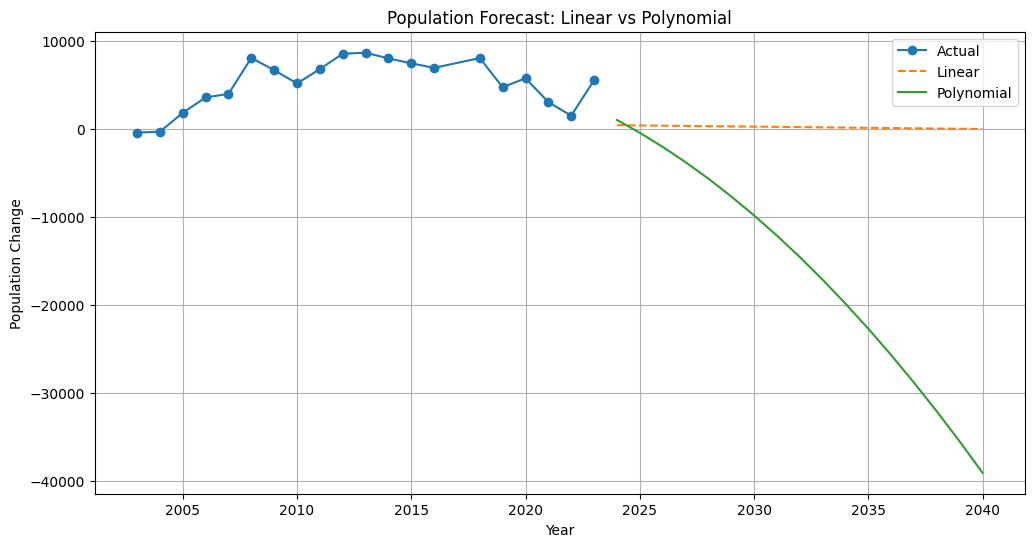

In [152]:
plt.figure(figsize=(12,6))

# Actual data
plt.plot(
    helsinki["Year"],
    helsinki["Population_Change"],
    marker="o",
    label="Actual"
)

# Linear prediction
plt.plot(
    future_years["Year"],
    predictions,
    linestyle="--",
    label="Linear"
)

# Polynomial prediction
plt.plot(
    future_years["Year"],
    predictions_poly,
    linestyle="-",
    label="Polynomial"
)

plt.title("Population Forecast: Linear vs Polynomial")
plt.xlabel("Year")
plt.ylabel("Population Change")

plt.legend()
plt.grid(True)
plt.show()

In [155]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Prepare Helsinki data
helsinki = data[data["Area"] == "Koko Helsinki"].copy()
helsinki = helsinki.sort_values("Year")

X = helsinki[["Year"]]
y = helsinki["Population_Change"]



In [156]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)
linear_pred_train = linear_model.predict(X)

poly_model = LinearRegression()
mse_linear = mean_squared_error(y, linear_pred_train)

print("Linear MSE:", mse_linear)


Linear MSE: 7103549.067591602


In [157]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model.fit(X_poly, y)
poly_pred_train = poly_model.predict(X_poly)
mse_poly = mean_squared_error(y, poly_pred_train)
print("Polynomial MSE:", mse_poly)

Polynomial MSE: 1739268.2217875891


I tested two models, Linear Regression and Polynomial Regression, to predict population change. The results showed that the polynomial model had a much lower error than the linear model, which means it fits the past data better. This is because population change does not follow a straight line and instead goes up and down over time, so a curved model can capture this pattern more accurately. However, when I looked at the graph, the polynomial model gave unrealistic future predictions, with values dropping sharply, which is not practical in real life. On the other hand, the linear model gives more stable and reasonable future estimates. Therefore, even though polynomial regression performs better on past data, I chose linear regression for forecasting because it provides more reliable long-term predictions.